<a href="https://colab.research.google.com/github/Itsukatsu/RFM_Analysis_My/blob/main/RFM_Analysis_My.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# 📊 客戶價值細分專案：基於 RFM 模型與 K-Means 演算法的客群分群分析

本專案旨在利用機器學習中的 **非監督式學習 (Unsupervised Learning)** 技術 —— **K-Means 分群演算法**，結合行銷學經典的 **RFM 模型**（Recency 近期消費天數、Frequency 消費頻率、Monetary 消費金額），對客戶進行深度價值劃分。藉此識別出核心 VIP、高價值回購客、新客以及流失客戶，以利企業制定精準的差異化行銷策略。

---

## 🛠️ 專案分析流程與實作步驟

### 1. 資料載入與 RFM 指標建構
* **原始資料處理**：讀取交易明細 `RFM_Raw.csv`，將欄位映射至 `Date`（日期）、`InvoNo`（發票/交易編號）、`CustomerKey`（客戶 ID）及 `Amount`（交易金額）。
* **RFM 指標定義與聚合**：
  * **F (Frequency)**：每位客戶的累計交易發票次數。
  * **M (Monetary)**：每位客戶的累計消費總金額。
  * **R (Recency)**：以整個資料集中的最晚交易日期作為基準日，計算每位客戶最後一次交易與該基準日的天數差。天數越小代表近期有消費，活躍度越高。

### 2. 特徵正規化 (Feature Scaling)
* 由於 R、F、M 的數值區間與計量單位差異極大（例如消費金額 M 高達數萬，而頻率 F 通常在數十以內），若直接進行分群，距離計算會嚴重偏向數值較大的特徵。
* 專案採用 **Min-Max 正規化 (Min-Max Normalization)**，將所有特徵等比例縮放至 `[0, 1]` 區間，確保分群模型的公平性與準確性。

### 3. 使用手肘法 (Elbow Method) 決定最佳群數
* 透過計算 $K=1$ 到 $K=10$ 的群內平方和 (Inertia/SSE)，繪製出手肘曲線圖。
* 根據曲線斜率變平緩的拐點（Elbow Point），最終選定 **$K=4$** 為最適客群細分數。

### 4. K-Means 聚類模型訓練與客群畫像分析
利用 $K=4$ 訓練模型後，成功將客戶分為 4 個具有顯著商業特徵的群體。以下為群體特徵統計：

| 客群編號 (Cluster) | 客戶數量 (Count) | 平均消費頻率 (F_Mean) | 平均消費金額 (M_Mean) | 平均未消費天數 (R_Mean) | 🎯 商業定位與建議策略 |
| :---: | :---: | :---: | :---: | :---: | :--- |
| **Cluster 1** | 75 | 3.64 次 | $8,586.61 | 183.65 天 | **流失/沉睡客戶**：久未消費且貢獻極低。建議以低成本的自動化 E-mail 或喚醒優惠嘗試啟用。
| **Cluster 2** | 131 | 26.02 次 | $74,066.83 | 14.79 天 | **核心 VIP 客戶**：近期有消費、頻率最高且貢獻金額最大。應提供專屬禮遇、優先體驗或高尊榮感的 VIP 活動以維持忠誠度。
| **Cluster 3** | 212 | 18.64 次 | $44,033.34 | 18.43 天 | **主力回購客戶**：消費頻率與貢獻度次高，近期活躍度極佳。可透過交叉銷售（Cross-selling）或滿額加購推薦，提升單次客單價。
| **Cluster 4** | 314 | 5.57 次 | $13,517.75 | 45.25 天 | **新客 / 潛在客戶**：交易次數偏低，但近期有過消費。應加強新手引導、發放首購後二次回購折價券，培養其品牌粘著度。

### 5. RFM 成對散布圖 (Pair Plot) 視覺化驗證
* 藉由 Seaborn 套件繪製 4 個客群在 `R`、`F`、`M` 兩兩維度下的成對散布圖（Pair Plot）。
* **分析結論**：在圖表中，四個顏色（客群）呈現出高度集中的分佈區塊，分群界線分明，未出現嚴重的重疊或雜亂分佈，證明本次 K-Means 模型分群效果極佳，能確實為業務決策提供有力依據。
```

# first Title
## Second Title
- item 1
- item 2
- item 3
**abcde**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("RFM_Data.csv")
df.head()

,Customer,F,M,R
0,A0350,25,51238.11440,9
1,A0351,6,17890.31200,16
2,A0352,14,46424.03852,14
3,A0353,14,27607.68636,24
4,A0354,6,9973.92064,31


In [24]:
import pandas as pd

# 1. 讀取原始資料集 RFM_Raw.csv
raw_df = pd.read_csv('RFM_Raw.csv')

# 2. 重新命名中文欄位，方便程式處理
raw_df = raw_df.rename(
    columns={
        "客戶ID": "CustomerKey",
        "日期": "Date",
        "發票編號": "InvoNo",
        "金額": "Amount",
    }
)

# 3. 確保日期欄位為 datetime 型態 (使用 format='mixed' 或嘗試自動解析)
raw_df["Date"] = pd.to_datetime(raw_df["Date"].astype(str).str.split('.').str[0], format='%Y%m%d', errors='coerce')

# 4. 設定基準日 (整個資料集中的最大日期)
max_dataset_date = raw_df["Date"].max()

# 5. 進行 groupby 與 RFM 聚合運算
rfm_result = (
    raw_df.groupby("CustomerKey")
    .agg(
        F=("InvoNo", "count"),             # F: InvoNo 計數
        M=("Amount", "sum"),                # M: 金額加總
        Max_Date=("Date", "max"),           # 找出每個客戶的最大交易日期
    )
    .reset_index()
)

# 6. 計算 R：基準日與客戶最大交易日期的天數差額
rfm_result["R"] = (max_dataset_date - rfm_result["Max_Date"]).dt.days

# 7. 整理欄位名稱與順序
rfm_result = rfm_result.rename(columns={"CustomerKey": "Customer"})
rfm_result = rfm_result[["Customer", "F", "M", "R"]]

# 顯示前 5 筆轉換結果
display(rfm_result.head())

,Customer,F,M,R
0,A0350,25,51238.11440,9
1,A0351,6,17890.31200,16
2,A0352,14,46424.03852,14
3,A0353,14,27607.68636,24
4,A0354,6,9973.92064,31


In [25]:
# 進行 Min-Max 正規化處理，並命名為 nrfm
nrfm = rfm_result.copy()

for col in ['F', 'M', 'R']:
    col_min = nrfm[col].min()
    col_max = nrfm[col].max()
    # 避免分母為 0 的情況
    if col_max - col_min != 0:
        nrfm[col] = (nrfm[col] - col_min) / (col_max - col_min)
    else:
        nrfm[col] = 0.0

# 顯示正規化後的結果
display(nrfm.head())

,Customer,F,M,R
0,A0350,0.631579,0.376563,0.024523
1,A0351,0.131579,0.127866,0.043597
2,A0352,0.342105,0.340662,0.038147
3,A0353,0.342105,0.200335,0.065395
4,A0354,0.131579,0.068827,0.084469


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak o

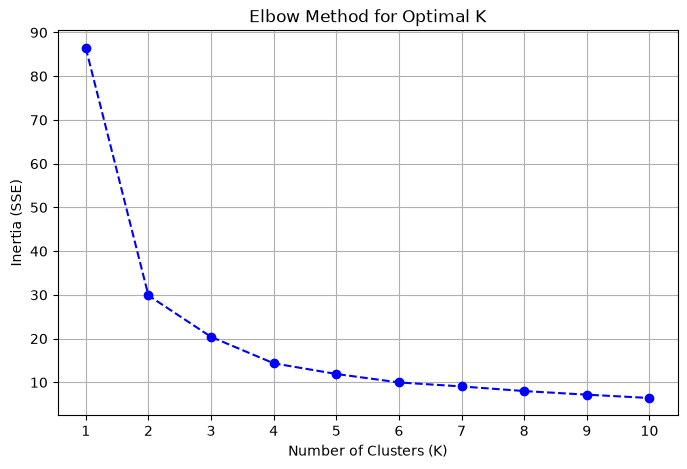

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 準備用於分群的資料 (排除非數值的 Customer 欄位)
X = nrfm[['F', 'M', 'R']]

# 2. 計算不同 K 值下的群內平方和 (SSE)
sse = []
k_range = range(1, 11)

for k in k_range:
    # 使用 random_state 確保每次執行結果一致
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# 3. 繪製手肘法圖 (Elbow Chart)
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [30]:
from sklearn.cluster import KMeans

# 1. 建立 KMeans 模型，設定分群數為 4
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init='auto')

# 2. 使用 normalized 的 F, M, R 欄位進行分群
features = nrfm[['F', 'M', 'R']]
kmeans_model.fit(features)

# 3. 將分群標籤加回原始與正規化的資料集中 (將群組標籤轉為 Cluster 1~4 方便識別)
rfm_result['Cluster'] = kmeans_model.labels_ + 1
nrfm['Cluster'] = kmeans_model.labels_ + 1

# 4. 統計每一群的客戶數量與 F, M, R 的平均值 (使用原始數值以便解讀實際商業意義)
cluster_summary = rfm_result.groupby('Cluster').agg(
    Customer_Count=('Customer', 'count'),
    F_Mean=('F', 'mean'),
    M_Mean=('M', 'mean'),
    R_Mean=('R', 'mean')
).reset_index()

print("=== 4 個客群的特徵統計資訊 ===")
display(cluster_summary)

print("\n=== 客戶分群明細預覽 ===")
display(rfm_result.head())



=== 4 個客群的特徵統計資訊 ===


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,Cluster,Customer_Count,F_Mean,M_Mean,R_Mean
0,1,75,3.640000,8586.611298,183.653333
1,2,131,26.015267,74066.827784,14.786260
2,3,212,18.636792,44033.340535,18.429245
3,4,314,5.570064,13517.754440,45.245223



=== 客戶分群明細預覽 ===


,Customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,2
1,A0351,6,17890.31200,16,4
2,A0352,14,46424.03852,14,3
3,A0353,14,27607.68636,24,3
4,A0354,6,9973.92064,31,4


In [31]:
rfm_result

,Customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,2
1,A0351,6,17890.31200,16,4
2,A0352,14,46424.03852,14,3
3,A0353,14,27607.68636,24,3
4,A0354,6,9973.92064,31,4
...,...,...,...,...,...
727,A1413,23,52738.79456,10,3
728,A1415,20,53019.49664,17,3
729,A1416,24,49938.38378,4,3
730,A1419,22,64257.84520,50,2


In [33]:
# 載入 Silhouette 套件，為驗證分組成效，需要執行 Silhouette 分析
from sklearn.metrics import silhouette_samples
silhouette=silhouette_samples(rfm_result[["R","F","M"]], rfm_result.Cluster)

C:\Users\student\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
C:\Users\student\anaconda3\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 0, 'Item No')

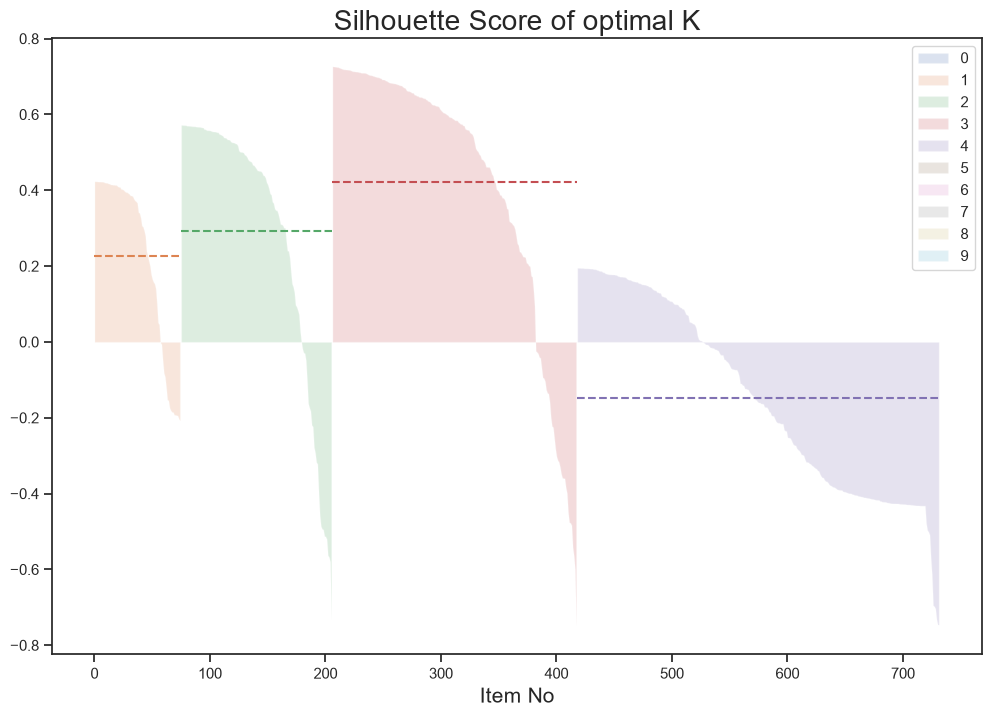

In [34]:
# 01 設定畫布尺寸
# 02 初始類別軸起始點
# 03 繪製 Silhouette 圖

#k=4 #承繼前段 k-means 分組數
plt.figure(figsize=[12,8]) #01
x0=0 #02

#03
for i in range(k):
   
    group_slh=silhouette[rfm_result.Cluster==i] # 取出 i 組 silhouette 分數表
    x=range(x0,x0+len(group_slh)) # 以 i 組序列範圍為類別軸 (x)

    y=-np.sort(-group_slh) # 將 i 組 silhouette 分數表依遞減排序，為數值軸 (y)
    yavg=np.average(group_slh) # 計算 i 組 silhouette 分數平均值，為數值軸參考線

    plt.fill_between(x,y,alpha=0.2,label=i) # 繪圖區填滿
 
    plt.plot([x0,x0+len(group_slh)],[yavg,yavg],'--') # 標註平均線
   
    plt.legend() # 繪製圖例
       
    x0=x0+len(group_slh) # 設定次組類別軸起始點

plt.title('Silhouette Score of optimal K',fontsize=20)
plt.xlabel('Item No',fontsize=15)

In [28]:
# 將分群標籤 Cluster 依照 Customer 對應回貼至原始資料 df
df = df.merge(rfm_result[['Customer', 'Cluster']], on='Customer', how='left')

# 顯示回貼標籤後的原始資料前 5 筆
display(df.head())

,Customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,2
1,A0351,6,17890.31200,16,4
2,A0352,14,46424.03852,14,3
3,A0353,14,27607.68636,24,3
4,A0354,6,9973.92064,31,4


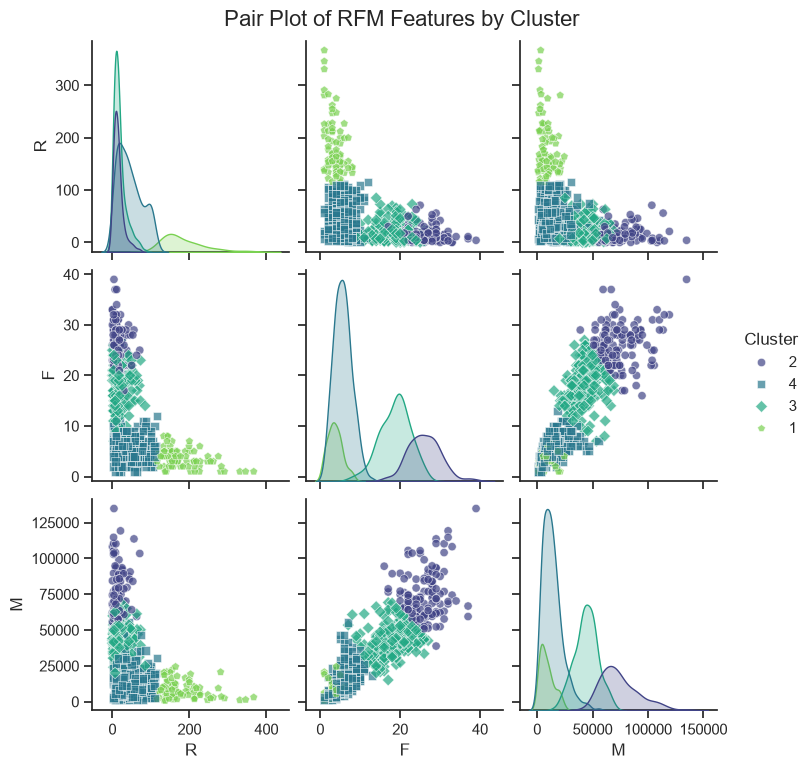

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定繪圖風格
sns.set_theme(style="ticks")

# 繪製 Pair Plot (成對散布圖)，以 Cluster 作為分類顏色
# 由於 Cluster例上 欄位是整數，我們將其轉換為類別型態 (str)，這樣在圖能更好地以離散顏色呈現
plot_df = df.copy()
plot_df['Cluster'] = plot_df['Cluster'].astype(str)

g = sns.pairplot(
    plot_df[['R', 'F', 'M', 'Cluster']],
    hue='Cluster',
    palette='viridis',
    markers=['o', 's', 'D', 'p'],
    diag_kind='kde',  # 對角線使用核密度估計圖呈現分佈
    plot_kws={'alpha': 0.7, 'edgecolor': 'w', 'linewidth': 0.5}
)

# 設定圖表標題
g.fig.suptitle('Pair Plot of RFM Features by Cluster', y=1.02, fontsize=16)
plt.show()